**Лабораторна робота №5**

Встановлення та імпорт необхідних бібліотек

In [2]:
!pip install pandas numpy torch scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Налаштування для відтворюваності результатів

In [3]:
np.random.seed(42)
torch.manual_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

Функція для oversampling (якщо weighted loss недостатньо, тільки для тренувального набору)

In [4]:
def apply_random_oversampling(X, y):
    from collections import Counter

    print(f"\nЗАСТОСУВАННЯ OVERSAMPLING:")
    print(f"До oversampling: {dict(Counter(y.numpy()))}")

    # Знаходимо максимальний розмір класу
    class_counts = np.bincount(y.numpy())
    max_count = class_counts.max()

    X_resampled = []
    y_resampled = []

    for class_idx in range(len(class_counts)):
        # Знаходимо всі індекси цього класу
        class_indices = np.where(y.numpy() == class_idx)[0]
        class_X = X[class_indices]
        class_y = y[class_indices]

        # Визначаємо скільки потрібно додати
        n_to_add = max_count - len(class_indices)

        if n_to_add > 0:
            # Випадково вибираємо зразки для дублювання
            random_indices = np.random.choice(len(class_indices), size=n_to_add, replace=True)
            class_X_oversampled = torch.cat([class_X, class_X[random_indices]], dim=0)
            class_y_oversampled = torch.cat([class_y, class_y[random_indices]], dim=0)
        else:
            class_X_oversampled = class_X
            class_y_oversampled = class_y

        X_resampled.append(class_X_oversampled)
        y_resampled.append(class_y_oversampled)

    X_resampled = torch.cat(X_resampled, dim=0)
    y_resampled = torch.cat(y_resampled, dim=0)

    # Перемішування
    shuffle_idx = torch.randperm(len(y_resampled))
    X_resampled = X_resampled[shuffle_idx]
    y_resampled = y_resampled[shuffle_idx]

    print(f"Після oversampling: {dict(Counter(y_resampled.numpy()))}")
    print(f"Розмір збільшився: {len(y)} → {len(y_resampled)}")
    print(f"Тепер всі класи мають однаковий розмір!\n")

    return X_resampled, y_resampled

Завантаження та попередня обробка даних

In [5]:
def load_and_preprocess_data():
    try:
        data = pd.read_csv('WineQT.csv')
    except:
        print("Помилка завантаження датасету.")
        return None

    print(f"\nРозмір датасету: {data.shape}")
    print(f"\nПерші рядки:\n{data.head()}")

    # Видаляємо стовпець Id якщо він є
    if 'Id' in data.columns:
        data = data.drop('Id', axis=1)
        print("\nСтовпець 'Id' видалено")

    # Відокремлення ознак та міток
    X = data.drop('quality', axis=1).values
    y = data['quality'].values

    print(f"\nАНАЛІЗ ДИСБАЛАНСУ КЛАСІВ:")
    print(f"Оригінальний розподіл якості вина:")
    unique, counts = np.unique(y, return_counts=True)
    for quality, count in zip(unique, counts):
        print(f"  Quality {quality}: {count} зразків ({count/len(y)*100:.1f}%)")

    # Об'єднання класів для балансу
    y_merged = np.zeros_like(y)

    # НОВИЙ КРАЩИЙ мапінг (3 класи - більш збалансовано):
    # 3,4,5 → 0 (Низька/Середня)
    # 6     → 1 (Добра)
    # 7,8   → 2 (Відмінна)

    # Використаємо 3 класи для балансу
    y_merged[y <= 5] = 0  # Низька/Середня (3-5): 522 зразки (45.7%)
    y_merged[y == 6] = 1  # Добра (6): 462 зразки (40.4%)
    y_merged[y >= 7] = 2  # Відмінна (7-8): 159 зразків (13.9%)

    y = y_merged

    print(f"\nНовий ЗБАЛАНСОВАНИЙ розподіл класів:")
    unique, counts = np.unique(y, return_counts=True)
    quality_names = ['Низька/Середня (3-5)', 'Добра (6)', 'Відмінна (7-8)']

    for cls, count in zip(unique, counts):
        percentage = count/len(y)*100
        status = "✓" if percentage > 10 else "⚠️"
        print(f"  {status} Class {cls} [{quality_names[cls]}]: {count} зразків ({percentage:.1f}%)")

    num_classes = len(np.unique(y))

    # Нормалізація ознак
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("\nОзнаки нормалізовані (StandardScaler)")

    # Розділення на train/val/test: 60%/20%/20%
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42, stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"\nРозділення даних:")
    print(f"  Train: {X_train.shape[0]} зразків")
    print(f"  Val:   {X_val.shape[0]} зразків")
    print(f"  Test:  {X_test.shape[0]} зразків")

    # Конвертація в PyTorch тензори
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)

    print("Дані конвертовані в PyTorch тензори\n")

    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test, num_classes = load_and_preprocess_data()


Розмір датасету: (1143, 13)

Перші рядки:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4       

Візуалізація розподілу класів

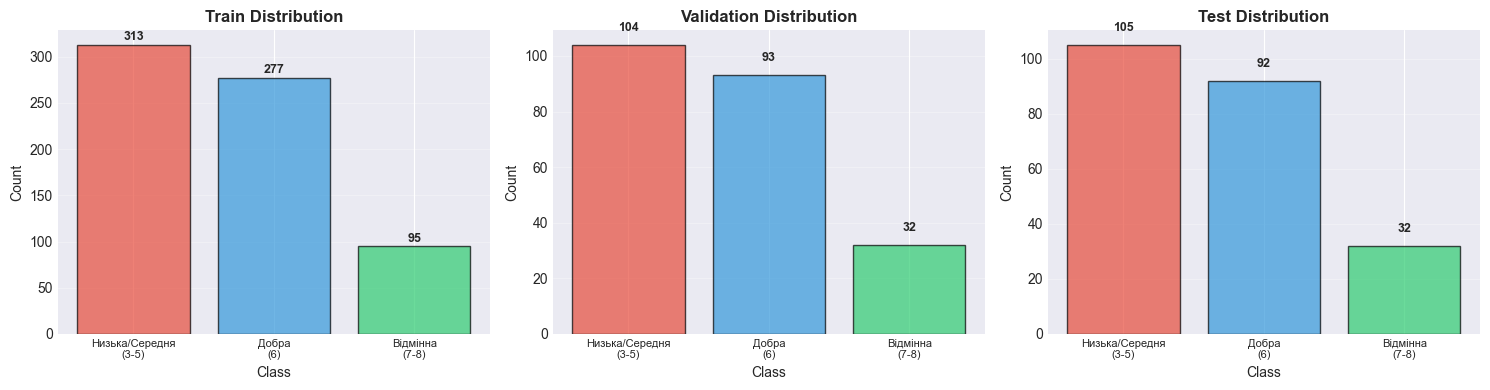

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = ['Низька/Середня\n(3-5)', 'Добра\n(6)', 'Відмінна\n(7-8)']

for idx, (data, name) in enumerate([(y_train, 'Train'),
                                     (y_val, 'Validation'),
                                     (y_test, 'Test')]):
    counts = np.bincount(data.numpy())
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    axes[idx].bar(range(len(counts)), counts, color=colors, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{name} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Class', fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].set_xticks(range(len(counts)))
    axes[idx].set_xticklabels(class_names, fontsize=8)
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Додаємо значення на стовпці
    for i, count in enumerate(counts):
        axes[idx].text(i, count + 5, str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

 Функції активації

*Функції активації вводять нелінійність у модель, що дозволяє мережі навчатися складним шаблонам. Кожна функція має forward та backward pass.*

In [8]:
class ActivationFunctions:
    @staticmethod
    def relu(x, derivative=False):
        if derivative:
            return (x > 0).float()
        return torch.maximum(torch.zeros_like(x), x)

    @staticmethod
    def tanh(x, derivative=False):
        if derivative:
            return 1 - torch.tanh(x)**2
        return torch.tanh(x)

    @staticmethod
    def sigmoid(x, derivative=False):
        if derivative:
            s = torch.sigmoid(x)
            return s * (1 - s)
        return torch.sigmoid(x)

    @staticmethod
    def softmax(x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

Тестування функцій активації

In [9]:
x_test = torch.tensor([[-2.0, -1.0, 0.0, 1.0, 2.0]])

print(f"\nВхід: {x_test}")
print(f"ReLU: {ActivationFunctions.relu(x_test)}")
print(f"ReLU derivative: {ActivationFunctions.relu(x_test, derivative=True)}")
print(f"Tanh: {ActivationFunctions.tanh(x_test)}")
print(f"Sigmoid: {ActivationFunctions.sigmoid(x_test)}")


Вхід: tensor([[-2., -1.,  0.,  1.,  2.]])
ReLU: tensor([[0., 0., 0., 1., 2.]])
ReLU derivative: tensor([[0., 0., 0., 1., 1.]])
Tanh: tensor([[-0.9640, -0.7616,  0.0000,  0.7616,  0.9640]])
Sigmoid: tensor([[0.1192, 0.2689, 0.5000, 0.7311, 0.8808]])


Функція втрат

*Categorical Cross-Entropy вимірює, наскільки прогнози моделі відрізняються від справжніх міток.*

In [10]:
class LossFunctions:
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False, class_weights=None):
        """
        Weighted Cross-Entropy для врахування дисбалансу класів

        Args:
            y_pred: передбачені ймовірності (batch_size, num_classes)
            y_true: справжні мітки (batch_size,)
            derivative: якщо True, повертає градієнт
            class_weights: ваги для класів (num_classes,)
        """
        batch_size = y_pred.shape[0]

        if derivative:
            grad = y_pred.clone()
            grad[range(batch_size), y_true] -= 1

            # Застосовуємо ваги класів до градієнта
            if class_weights is not None:
                weight_per_sample = class_weights[y_true]
                grad = grad * weight_per_sample.unsqueeze(1)

            return grad / batch_size

        # Forward pass
        epsilon = 1e-15
        y_pred_clipped = torch.clip(y_pred, epsilon, 1 - epsilon)
        correct_confidences = y_pred_clipped[range(batch_size), y_true]

        loss = -torch.log(correct_confidences)

        # Застосовуємо ваги класів
        if class_weights is not None:
            weight_per_sample = class_weights[y_true]
            loss = loss * weight_per_sample

        return torch.mean(loss)

Тестуємо функцію втрат

In [11]:
y_pred_test = torch.tensor([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1]])
y_true_test = torch.tensor([0, 1])

loss = LossFunctions.categorical_cross_entropy(y_pred_test, y_true_test)
grad = LossFunctions.categorical_cross_entropy(y_pred_test, y_true_test, derivative=True)

print(f"Передбачені ймовірності:\n{y_pred_test}")
print(f"Справжні мітки: {y_true_test}")
print(f"Loss: {loss.item():.4f}")
print(f"Gradient:\n{grad}")

Передбачені ймовірності:
tensor([[0.7000, 0.2000, 0.1000],
        [0.1000, 0.8000, 0.1000]])
Справжні мітки: tensor([0, 1])
Loss: 0.2899
Gradient:
tensor([[-0.1500,  0.1000,  0.0500],
        [ 0.0500, -0.1000,  0.0500]])


Власна реалізація багатошарового перцептрону

*Реалізує forward propagation, backward propagation та gradient descent з нуля, використовуючи тільки базові операції PyTorch.*

In [12]:
class CustomMLP:
    def __init__(self, layer_sizes, activations, learning_rate=0.01,
                 momentum=0.9, weight_decay=0.0001):
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.parameters = {}
        self.velocities = {}
        self.num_layers = len(layer_sizes)

        # Xavier ініціалізація
        for i in range(1, self.num_layers):
            limit = np.sqrt(6.0 / (layer_sizes[i-1] + layer_sizes[i]))

            self.parameters[f'W{i}'] = torch.randn(
                layer_sizes[i], layer_sizes[i-1]
            ) * limit
            self.parameters[f'b{i}'] = torch.zeros(layer_sizes[i], 1)

            # Ініціалізація velocity для momentum
            self.velocities[f'W{i}'] = torch.zeros_like(self.parameters[f'W{i}'])
            self.velocities[f'b{i}'] = torch.zeros_like(self.parameters[f'b{i}'])

        print(f"Власна мережа ініціалізована:")
        print(f"  Архітектура: {layer_sizes}")
        print(f"  Learning rate: {learning_rate}")
        print(f"  Momentum: {momentum}")
        print(f"  Weight decay: {weight_decay}")

    def forward(self, X, training=True):
        """Forward propagation"""
        A_prev = X.T
        cache = {'A0': A_prev}

        for i in range(1, self.num_layers):
            Z = self.parameters[f'W{i}'] @ A_prev + self.parameters[f'b{i}']

            if i == self.num_layers - 1:
                A = ActivationFunctions.softmax(Z.T).T
            else:
                activation_name = self.activations[i-1]
                if activation_name == 'relu':
                    A = ActivationFunctions.relu(Z)
                elif activation_name == 'tanh':
                    A = ActivationFunctions.tanh(Z)
                elif activation_name == 'sigmoid':
                    A = ActivationFunctions.sigmoid(Z)

            if training:
                cache[f'Z{i}'] = Z
                cache[f'A{i}'] = A

            A_prev = A

        output = A.T
        if training:
            return output, cache
        return output

    def backward(self, X, y, cache, class_weights=None, clip_value=5.0):
        """Backward propagation з gradient clipping та momentum"""
        batch_size = X.shape[0]

        # Градієнт вихідного шару
        output = cache[f'A{self.num_layers-1}'].T
        dZ = LossFunctions.categorical_cross_entropy(
            output, y, derivative=True, class_weights=class_weights
        ).T

        # Backpropagation через шари
        for i in range(self.num_layers - 1, 0, -1):
            A_prev = cache[f'A{i-1}']

            # Градієнти
            dW = dZ @ A_prev.T
            db = torch.sum(dZ, dim=1, keepdim=True)

            # L2 регуляризація (weight decay)
            dW += self.weight_decay * self.parameters[f'W{i}']

            # Gradient clipping
            dW = torch.clamp(dW, -clip_value, clip_value)
            db = torch.clamp(db, -clip_value, clip_value)

            # Momentum оновлення
            self.velocities[f'W{i}'] = (self.momentum * self.velocities[f'W{i}'] +
                                        self.learning_rate * dW)
            self.velocities[f'b{i}'] = (self.momentum * self.velocities[f'b{i}'] +
                                        self.learning_rate * db)

            self.parameters[f'W{i}'] -= self.velocities[f'W{i}']
            self.parameters[f'b{i}'] -= self.velocities[f'b{i}']

            # Градієнт для попереднього шару
            if i > 1:
                dA_prev = self.parameters[f'W{i}'].T @ dZ
                Z_prev = cache[f'Z{i-1}']
                activation_name = self.activations[i-2]

                if activation_name == 'relu':
                    dZ = dA_prev * ActivationFunctions.relu(Z_prev, derivative=True)
                elif activation_name == 'tanh':
                    dZ = dA_prev * ActivationFunctions.tanh(Z_prev, derivative=True)
                elif activation_name == 'sigmoid':
                    dZ = dA_prev * ActivationFunctions.sigmoid(Z_prev, derivative=True)

    def train(self, X_train, y_train, X_val, y_val, epochs=500,
              patience=50, verbose=True, class_weights=None):
        """
        Навчання з Early Stopping та weighted loss
        """
        # Якщо ваги не передані, обчислюємо їх
        if class_weights is None:
            class_counts = torch.bincount(y_train).float()
            n_samples = len(y_train)
            n_classes = len(class_counts)
            class_weights = n_samples / (n_classes * class_counts)

        print(f"\nВаги класів для балансування:")
        for i, weight in enumerate(class_weights):
            print(f"  Class {i}: {weight:.3f}")

        history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': []
        }

        best_val_loss = float('inf')
        patience_counter = 0
        best_params = None

        print(f"\nПочаток навчання (epochs={epochs}, patience={patience})\n")

        for epoch in range(epochs):
            # Forward pass
            output, cache = self.forward(X_train, training=True)

            # Loss
            train_loss = LossFunctions.categorical_cross_entropy(
                output, y_train, class_weights=class_weights
            )

            # Backward pass
            self.backward(X_train, y_train, cache, class_weights=class_weights)

            # Accuracy
            train_pred = torch.argmax(output, dim=1)
            train_acc = (train_pred == y_train).float().mean().item()

            # Validation
            val_output = self.forward(X_val, training=False)
            val_loss = LossFunctions.categorical_cross_entropy(
                val_output, y_val, class_weights=class_weights
            )
            val_pred = torch.argmax(val_output, dim=1)
            val_acc = (val_pred == y_val).float().mean().item()

            # History
            history['train_loss'].append(train_loss.item())
            history['val_loss'].append(val_loss.item())
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_params = {k: v.clone() for k, v in self.parameters.items()}
            else:
                patience_counter += 1

            # Виведення
            if verbose and (epoch % 50 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:3d} | "
                      f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                      f"Patience: {patience_counter}/{patience}")

            # Early stopping
            if patience_counter >= patience:
                print(f"\nEarly stopping на epoch {epoch}")
                break

        # Відновлення найкращих параметрів
        if best_params is not None:
            self.parameters = best_params
            print(f"Відновлено найкращу модель (Val Loss: {best_val_loss:.4f})")

        return history

    def predict(self, X):
        """Передбачення"""
        output = self.forward(X, training=False)
        return torch.argmax(output, dim=1)

Створення та навчання власної моделі

In [13]:
input_size = X_train.shape[1]
custom_model = CustomMLP(
    layer_sizes=[input_size, 64, 32, num_classes],
    activations=['relu', 'relu', 'softmax'],
    learning_rate=0.01,
    momentum=0.9,
    weight_decay=0.0001
)

history_custom = custom_model.train(
    X_train, y_train,
    X_val, y_val,
    epochs=500,
    patience=50,
    verbose=True,
    class_weights=None
)

# Тестування
y_pred_custom = custom_model.predict(X_test)
test_acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"\nТочність на тестовій вибірці: {test_acc_custom:.4f}")
print(f"\nЗвіт класифікації:\n{classification_report(y_test, y_pred_custom)}")

Власна мережа ініціалізована:
  Архітектура: [11, 64, 32, 3]
  Learning rate: 0.01
  Momentum: 0.9
  Weight decay: 0.0001

Ваги класів для балансування:
  Class 0: 0.729
  Class 1: 0.824
  Class 2: 2.404

Початок навчання (epochs=500, patience=50)

Epoch   0 | Train Loss: 3.1527, Acc: 0.4248 | Val Loss: 3.1119, Acc: 0.4192 | Patience: 0/50
Epoch  50 | Train Loss: 0.6950, Acc: 0.6175 | Val Loss: 0.8382, Acc: 0.6114 | Patience: 0/50
Epoch 100 | Train Loss: 0.6265, Acc: 0.6686 | Val Loss: 0.8197, Acc: 0.6463 | Patience: 0/50
Epoch 150 | Train Loss: 0.5846, Acc: 0.6978 | Val Loss: 0.8119, Acc: 0.6725 | Patience: 0/50
Epoch 200 | Train Loss: 0.5522, Acc: 0.7109 | Val Loss: 0.8123, Acc: 0.6812 | Patience: 20/50

Early stopping на epoch 230
Відновлено найкращу модель (Val Loss: 0.8103)

Точність на тестовій вибірці: 0.6245

Звіт класифікації:
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       105
           1       0.56      0.57      0.56

PyTorch реалізація для порівняння

In [14]:
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout=0.3):
        super(PyTorchMLP, self).__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

        # He ініціалізація для ReLU
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)

Навчання PyTorch моделі з використанням вбудованих інструментів.

In [15]:
def train_pytorch_model(model, X_train, y_train, X_val, y_val,
                                   epochs=500, patience=50, class_weights=None):
    # Якщо ваги не передані, обчислюємо їх
    if class_weights is None:
        class_counts = torch.bincount(y_train).float()
        n_samples = len(y_train)
        n_classes = len(class_counts)
        class_weights = n_samples / (n_classes * class_counts)

    print(f"\nВаги класів для PyTorch:")
    for i, weight in enumerate(class_weights):
        print(f"  Class {i}: {weight:.3f}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Adam оптимізатор з weight decay
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=0.001,
                                 weight_decay=0.01)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    print(f"\nПочаток навчання PyTorch (epochs={epochs}, patience={patience})\n")

    for epoch in range(epochs):
        # Training
        model.train()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        _, train_pred = torch.max(outputs, 1)
        train_acc = (train_pred == y_train).float().mean().item()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            _, val_pred = torch.max(val_outputs, 1)
            val_acc = (val_pred == y_val).float().mean().item()

        # Scheduler
        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        # History
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Виведення
        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} | "
                  f"Train Loss: {loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                  f"Patience: {patience_counter}/{patience}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping на epoch {epoch}")
            break

    # Відновлення найкращої моделі
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Відновлено найкращу модель (Val Loss: {best_val_loss:.4f})")

    return history

Створення та навчання PyTorch моделі

In [16]:
pytorch_model = PyTorchMLP(
    input_size=input_size,
    hidden_sizes=[64, 32],
    output_size=num_classes,
    dropout=0.3
)

print(f"\nАрхітектура:\n{pytorch_model}\n")

history_pytorch = train_pytorch_model(
    pytorch_model,
    X_train, y_train,
    X_val, y_val,
    epochs=500,
    patience=50,
    class_weights=None
)

# Тестування PyTorch моделі
pytorch_model.eval()
with torch.no_grad():
    test_outputs = pytorch_model(X_test)
    _, y_pred_pytorch = torch.max(test_outputs, 1)

test_acc_pytorch = accuracy_score(y_test, y_pred_pytorch)

print(f"\nТочність на тестовій вибірці: {test_acc_pytorch:.4f}")
print(f"\nЗвіт класифікації:\n{classification_report(y_test, y_pred_pytorch)}")


Архітектура:
PyTorchMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
)


Ваги класів для PyTorch:
  Class 0: 0.729
  Class 1: 0.824
  Class 2: 2.404

Початок навчання PyTorch (epochs=500, patience=50)

Epoch   0 | Train Loss: 2.8290, Acc: 0.3212 | Val Loss: 1.5945, Acc: 0.3057 | Patience: 0/50
Epoch  50 | Train Loss: 1.3236, Acc: 0.5139 | Val Loss: 0.9736, Acc: 0.5764 | Patience: 0/50
Epoch 100 | Train Loss: 1.0688, Acc: 0.5212 | Val Loss: 0.9319, Acc: 0.6157 | Patience: 3/50
Epoch 150 | Train Loss: 0.9644, Acc: 0.5679 | Val Loss: 0.8981, Ac

Візуалізація історії навчання

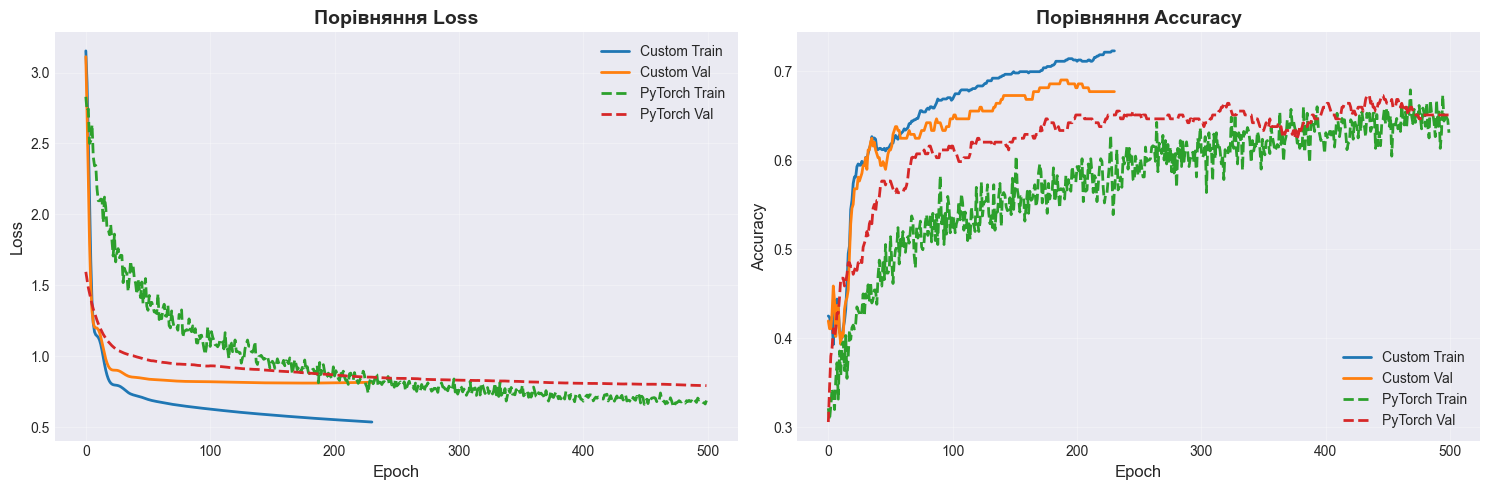


АНАЛІЗ НАВЧАННЯ

Власна реалізація:
  Фінальний Train Loss: 0.5357
  Фінальний Val Loss: 0.8157
  Різниця (Overfitting): 0.2800

PyTorch реалізація:
  Фінальний Train Loss: 0.6873
  Фінальний Val Loss: 0.7922
  Різниця (Overfitting): 0.1049


In [17]:
def plot_training_history(history_custom, history_pytorch):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history_custom['train_loss'], label='Custom Train', linewidth=2)
    axes[0].plot(history_custom['val_loss'], label='Custom Val', linewidth=2)
    axes[0].plot(history_pytorch['train_loss'], label='PyTorch Train',
                 linewidth=2, linestyle='--')
    axes[0].plot(history_pytorch['val_loss'], label='PyTorch Val',
                 linewidth=2, linestyle='--')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Порівняння Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history_custom['train_acc'], label='Custom Train', linewidth=2)
    axes[1].plot(history_custom['val_acc'], label='Custom Val', linewidth=2)
    axes[1].plot(history_pytorch['train_acc'], label='PyTorch Train',
                 linewidth=2, linestyle='--')
    axes[1].plot(history_pytorch['val_acc'], label='PyTorch Val',
                 linewidth=2, linestyle='--')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Порівняння Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Аналіз overfitting
    print("\nАНАЛІЗ НАВЧАННЯ")

    print("\nВласна реалізація:")
    print(f"  Фінальний Train Loss: {history_custom['train_loss'][-1]:.4f}")
    print(f"  Фінальний Val Loss: {history_custom['val_loss'][-1]:.4f}")
    print(f"  Різниця (Overfitting): {abs(history_custom['train_loss'][-1] - history_custom['val_loss'][-1]):.4f}")

    print("\nPyTorch реалізація:")
    print(f"  Фінальний Train Loss: {history_pytorch['train_loss'][-1]:.4f}")
    print(f"  Фінальний Val Loss: {history_pytorch['val_loss'][-1]:.4f}")
    print(f"  Різниця (Overfitting): {abs(history_pytorch['train_loss'][-1] - history_pytorch['val_loss'][-1]):.4f}")

plot_training_history(history_custom, history_pytorch)

Матриця плутанини

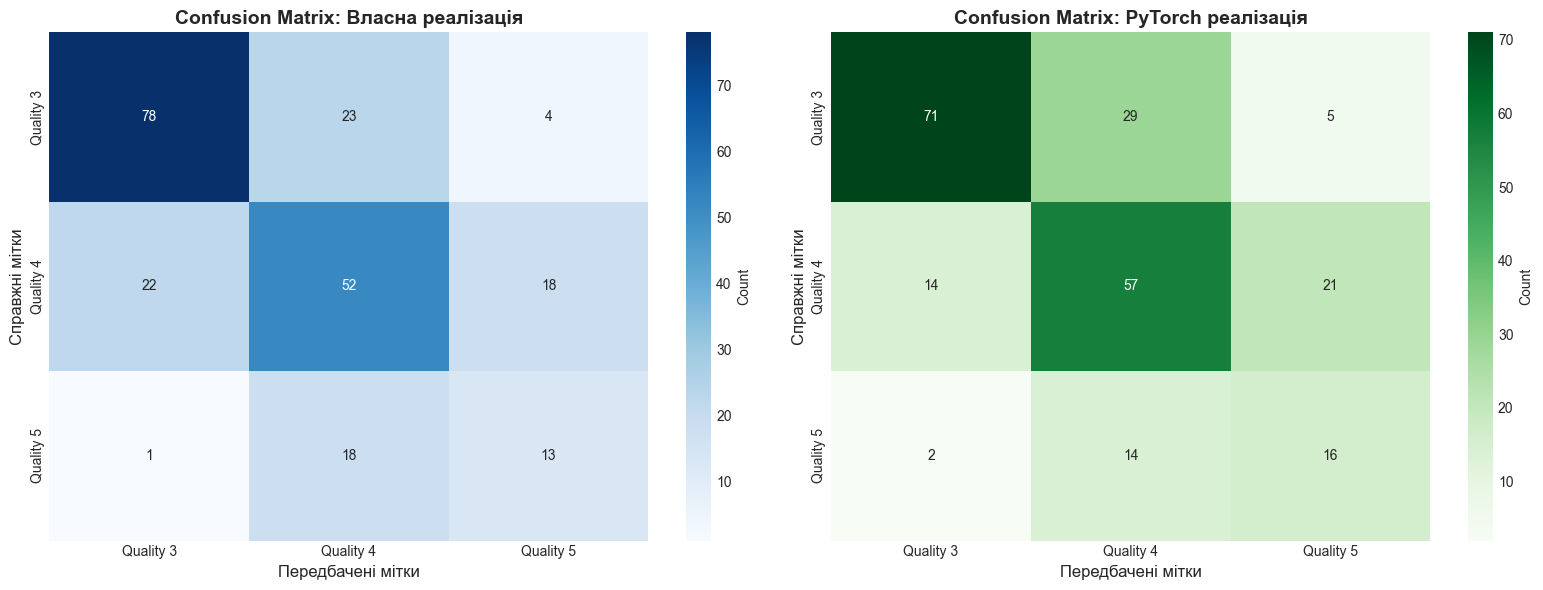


АНАЛІЗ ПОМИЛОК

Власна реалізація:
  Class 0: Precision=0.772, Recall=0.743
  Class 1: Precision=0.559, Recall=0.565
  Class 2: Precision=0.371, Recall=0.406

PyTorch реалізація:
  Class 0: Precision=0.816, Recall=0.676
  Class 1: Precision=0.570, Recall=0.620
  Class 2: Precision=0.381, Recall=0.500


In [18]:
def plot_confusion_matrix(y_true, y_pred_custom, y_pred_pytorch, class_names=None):
    if class_names is None:
        class_names = [f'Class {i}' for i in range(num_classes)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Власна реалізація
    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('Confusion Matrix: Власна реалізація',
                      fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Справжні мітки', fontsize=12)
    axes[0].set_xlabel('Передбачені мітки', fontsize=12)

    # PyTorch реалізація
    cm_pytorch = confusion_matrix(y_true, y_pred_pytorch)
    sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Count'})
    axes[1].set_title('Confusion Matrix: PyTorch реалізація',
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Справжні мітки', fontsize=12)
    axes[1].set_xlabel('Передбачені мітки', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Аналіз помилок
    print("\nАНАЛІЗ ПОМИЛОК")

    # Власна реалізація
    print("\nВласна реалізація:")
    for i in range(num_classes):
        precision = cm_custom[i, i] / cm_custom[:, i].sum() if cm_custom[:, i].sum() > 0 else 0
        recall = cm_custom[i, i] / cm_custom[i, :].sum() if cm_custom[i, :].sum() > 0 else 0
        print(f"  Class {i}: Precision={precision:.3f}, Recall={recall:.3f}")

    # PyTorch реалізація
    print("\nPyTorch реалізація:")
    for i in range(num_classes):
        precision = cm_pytorch[i, i] / cm_pytorch[:, i].sum() if cm_pytorch[:, i].sum() > 0 else 0
        recall = cm_pytorch[i, i] / cm_pytorch[i, :].sum() if cm_pytorch[i, :].sum() > 0 else 0
        print(f"  Class {i}: Precision={precision:.3f}, Recall={recall:.3f}")

# Назви класів (якість вина: 0-5 відповідає оригінальним 3-8)
class_names = [f'Quality {i+3}' for i in range(num_classes)]
plot_confusion_matrix(y_test, y_pred_custom, y_pred_pytorch, class_names)

Порівняльна таблиця результатів

In [19]:
comparison_data = {
    'Метрика': [
        'Test Accuracy',
        'Train Loss (final)',
        'Val Loss (final)',
        'Overfitting Gap'
    ],
    'Власна реалізація': [
        f"{test_acc_custom:.4f}",
        f"{history_custom['train_loss'][-1]:.4f}",
        f"{history_custom['val_loss'][-1]:.4f}",
        f"{abs(history_custom['train_loss'][-1] - history_custom['val_loss'][-1]):.4f}"
    ],
    'PyTorch реалізація': [
        f"{test_acc_pytorch:.4f}",
        f"{history_pytorch['train_loss'][-1]:.4f}",
        f"{history_pytorch['val_loss'][-1]:.4f}",
        f"{abs(history_pytorch['train_loss'][-1] - history_pytorch['val_loss'][-1]):.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n{comparison_df.to_string(index=False)}")


           Метрика Власна реалізація PyTorch реалізація
     Test Accuracy            0.6245             0.6288
Train Loss (final)            0.5357             0.6873
  Val Loss (final)            0.8157             0.7922
   Overfitting Gap            0.2800             0.1049
